<a href="https://colab.research.google.com/github/CD-GRUPO3/TA047R-1C2025-GRUPO03/blob/main/TA047R_TP2_GRUPO03_CHPX_ENTREGA_N3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Grupo 3 - Trabajo Práctico 2
###Redes neuronales

**Integrantes:**
- ARIAS, Rafaela Pilar. 112272. rparias@fi.uba.ar.
- BARCALA ROCA, Ramiro. 112478. rbarcala@fi.uba.ar.
- LEMA, Mora. 111831. molema@fi.uba.ar.
- IENCO, Lara Eliana. 111921. lienco@fi.uba.ar.


###Inicialización del entorno


In [1]:
# Importar las bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento de texto
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [2]:
#librerias necesarias para emmbedding
!pip install torch==2.2.0 torchtext==0.17.0 numpy==1.26.4

In [3]:
!pip install nltk

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
#Cargamos los datos al Notebook

!gdown 1rbGVg-g0_H4UxviHdM3KFEHv5_DjJd-P
!gdown 19RRGPOcV-gQojb7G3wCtu1pY2Q4fQs_y

Downloading...
From: https://drive.google.com/uc?id=1rbGVg-g0_H4UxviHdM3KFEHv5_DjJd-P
To: /content/test.csv
100% 11.1M/11.1M [00:00<00:00, 37.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=19RRGPOcV-gQojb7G3wCtu1pY2Q4fQs_y
To: /content/train.csv
100% 72.2M/72.2M [00:00<00:00, 83.2MB/s]


In [5]:
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

print("Train - Columnas:", train_df.shape[1], "Filas:", train_df.shape[0])
print("Test - Columnas:", test_df.shape[1], "Filas:", test_df.shape[0])

print("\nPrimeras filas del train:")
display(train_df.head())

print("\nColumnas del train:")
print(train_df.columns)

print("\nDistribución de clases:")
print(train_df['sentimiento'].value_counts())


Train - Columnas: 3 Filas: 50000
Test - Columnas: 2 Filas: 8599

Primeras filas del train:


,ID,review_es,sentimiento
0,0,Uno de los otros críticos ha mencionado que de...,positivo
1,1,Una pequeña pequeña producción.La técnica de f...,positivo
2,2,Pensé que esta era una manera maravillosa de p...,positivo
3,3,"Básicamente, hay una familia donde un niño peq...",negativo
4,4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo



Columnas del train:
Index(['ID', 'review_es', 'sentimiento'], dtype='object')

Distribución de clases:
sentimiento
positivo    25000
negativo    25000
Name: count, dtype: int64


###Limpieza y Tokenización


Veamos si las clases están balanceadas

In [6]:
train_df['sentimiento'].value_counts()

,count
sentimiento,
positivo,25000
negativo,25000


Separamos el dataset en entrenamiento 80% y test 20%

In [7]:
X = train_df['review_es']
y = train_df['sentimiento']

#Stratify para balancear la división
X_train_text, X_val_text, y_train, y_val = train_test_split(X,
                                                            y,
                                                            test_size = 0.2,
                                                            random_state = 42,
                                                            stratify = y
)

In [8]:
y_train.value_counts()

,count
sentimiento,
positivo,20000
negativo,20000


In [9]:
y_val.value_counts()

,count
sentimiento,
negativo,5000
positivo,5000


In [10]:
!pip install langid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 41.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=acb4d4ce827b8ac85b05d6fcf2a74e32b3d3415248f4d201fdf1e355b4423fc3
  Stored in directory: /root/.cache/pip/wheels/32/6a/b6/b7eb43a6ad55b139c15c5daa29f3707659cfa6944d3c696f5b
Successfully built langid


In [11]:
import langid

In [12]:
def detect_language(text):
    return langid.classify(str(text))[0]  # str() por si hay NaNs o números

train_df['language'] = train_df['review_es'].apply(detect_language)
test_df['language'] = test_df['review_es'].apply(detect_language)

Veamos cuántos idiomas hay y cuántas críticas por cada uno

In [13]:
conteo_idiomas_train = train_df['language'].value_counts()
print("Cantidad de idiomas en el dataset de entrenamiento: ", conteo_idiomas_train)
print(f"Cantidad de idiomas distintos: {train_df['language'].nunique()}")
conteo_idiomas_test = test_df['language'].value_counts()
print("\nCantidad de idiomas en el dataset de test: ", conteo_idiomas_test)


Cantidad de idiomas en el dataset de entrenamiento:  language
es    48179
en     1817
gl        2
pt        1
id        1
Name: count, dtype: int64
Cantidad de idiomas distintos: 5

Cantidad de idiomas en el dataset de test:  language
es    8597
ga       1
la       1
Name: count, dtype: int64


Nos quedamos sólo con las críticas en español

In [14]:
train_df = train_df[train_df['language'] == 'es'].copy()

In [15]:
print(train_df.shape)

(48179, 4)


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluar(y_true, y_pred, nombre):
    print(f"--- {nombre} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, pos_label='positivo'):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, pos_label='positivo'):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, pos_label='positivo'):.4f}")
    print()

---
#Redes Neuronales
---

In [17]:
%pip install transformers

In [18]:
!pip install --upgrade transformers
!pip install --upgrade transformers timm


from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader


from textwrap import wrap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 115.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.52.4
    Uninstalling transformers-4.52.4:
      Successfully uninstalled transformers-4.52.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

Inicializamos constantes

In [19]:
#Inicializamos los distintos parámetros
RANDOM_SEED = 42
MAX_LEN = 128 #Tamaño máximo del input (tokens)
BATCH_SIZE = 16 #Tamaño del batch, cantidad de reviews que se procesan juntas en una sola pasada por el modelo (forward y backward).
                #Batch grande = entrenamiento más rápido pero requiere más memoria. Batch chico = más estable pero más lento.
NCLASSES = 2
EPOCHS = 3 #Una pasada completa por todo el dataset de entrenamiento.
L_RATE = 2e-5 #Learning rate. Si es muy grande: el modelo aprende rápido pero puede volverse inestable o saltarse el mínimo.
                #Si es muy chica: el modelo aprende lentamente o queda estancado.
DROPOUT= 0.5

#Guardamos el modelo
model_name = "dccuchile/bert-base-spanish-wwm-cased"

#Fijamos las semillas
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

#Verificamos que estemos usando la GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


Convertimos la variable categórica sentimiento a una variable binaria, 1 pos, 0 neg.

In [20]:
train_df['label'] = (train_df['sentimiento'] == 'positivo').astype(int)

Elegimos el modelo a usar y su tokenizer correspondiente

In [21]:
#TOKENIZACIÓN
PRE_TRAINED_MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'

#Cargamos el tokenizador BERT en español entrenado por la Universidad de Chile.
tokenizer = AutoTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

In [22]:
#Dataset personalizado

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }


Para cada review:
*   Se convierte en texto plano.
*   Se tokeniza con el tokenizer de BERT (incluso se agrega el [CLS] y [SEP]).
*   Se codifica a IDs (input_ids).
*   Se crea la máscara de atención (attention_mask).

La clase TextDataset empaqueta esto para que PyTorch lo pueda leer por batch.

Convertimos los datos en estructuras que PyTorch puede usar para entrenar y evaluar.

In [23]:
#Construimos un PyTorch DataLoader a partir de un DataFrame
def data_loader(df, tokenizer, max_len, batch_size):
    dataset = TextDataset(
        texts=df["review_es"].to_numpy(),
        labels=df["label"].to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(dataset, batch_size=batch_size, num_workers=2)

Creamos un nuevo DataFrame de validación, con dos columnas:

* review_es: las críticas que quedaron como conjunto de validación (20% del total).
* label: las etiquetas binarias (0 o 1), generadas igual que antes.

PyTorch no puede trabajar directamente con DataFrames o listas. Necesita que los datos estén en un Dataset y luego en un DataLoader, con los batch.

In [24]:
val_df = pd.DataFrame({
    'review_es': X_val_text,
    'label': (y_val == 'positivo').astype(int)
})

In [25]:
train_data_loader = data_loader(train_df, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = data_loader(val_df, tokenizer, MAX_LEN, BATCH_SIZE)


Configuramos el modelo preentrenado BERT desde Hugging Face.

Es dccuchile/bert-base-spanish-wwm-cased, entrenado específicamente para el español.

Además, usamos dropout que desactiva aleatoriamente el 30% de las neuronas durante el entrenamiento para evitar el overfitting.

In [26]:
class BERTSentimentClassifier(nn.Module):

  def __init__(self, n_classes):
    super(BERTSentimentClassifier, self).__init__()
    self.bert = AutoModel.from_pretrained(PRE_TRAINED_MODEL_NAME,return_dict=False)
    self.drop = nn.Dropout(p=DROPOUT) #Evitamos el sobreentrenamiento (durante el entrenamiento, apagamos aleatoriamente el 50% de las neuronas)
    self.linear = nn.Linear(self.bert.config.hidden_size, n_classes) #768 neuronas de salidas de BERT, n_classes = 2 (positivo/negativo)

  #Otro requerimiento de PyTorch: tengemos que especificar el orden de las capas neuronales
  def forward(self, input_ids, attention_mask):
    _, cls_output = self.bert(
        input_ids = input_ids,
        attention_mask = attention_mask
    )
    drop_output = self.drop(cls_output)
    output = self.linear(drop_output)
    return output

In [27]:
model = BERTSentimentClassifier(2).to(device)

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Configuramos el entrenamiento de la red. Utilizamos AdamW como optimizador con el learning rate establecido al principio y definimos la cantidad de iteraciones (8000).

In [28]:
optimizer = AdamW(model.parameters(), L_RATE)
total_steps = len(train_data_loader) * EPOCHS  # 500 (500 lotes de 16 registros me da 8000)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps = 0,
    num_training_steps = total_steps
)
loss_fn = nn.CrossEntropyLoss().to(device)

Definimos las funciones de train y evaluation para el modelo

In [29]:
#Iteración entrenamiento
def train_model(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
  model = model.train() #Rrequerimiento de pytorch, debe estar en modo train
  losses = []
  correct_predictions = 0
  for batch in data_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['label'].to(device)
    outputs = model(input_ids = input_ids, attention_mask = attention_mask)
    _, preds = torch.max(outputs, dim=1) #Vemos cuál es la máxima de las 2 salidas
    loss = loss_fn(outputs, labels) #Calculamos la funcion de perdida de forma manual
    correct_predictions += torch.sum(preds == labels) #Predicciones a corregir
    losses.append(loss.item())
    loss.backward() #Aplicamos backpropagation
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) #Normalización del gradiente, para mejorar el entrenamiento
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad() #Reseteamos gradientes para la próxima iteración
  return correct_predictions.double()/n_examples, np.mean(losses)

def eval_model(model, data_loader, loss_fn, device, n_examples):
  model = model.eval() #Testeamos el modelo pasa a modo eval
  losses = []
  correct_predictions = 0
  with torch.no_grad(): #No modificamos ningún parámetro
    for batch in data_loader:
      input_ids = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['label'].to(device)
      outputs = model(input_ids = input_ids, attention_mask = attention_mask)
      _, preds = torch.max(outputs, dim=1)
      loss = loss_fn(outputs, labels)
      correct_predictions += torch.sum(preds == labels)
      losses.append(loss.item())
  return correct_predictions.double()/n_examples, np.mean(losses)

Verificamos que efectivamente estamos trabajando con GPU antes de entrenar!

In [30]:
torch.cuda.get_device_name(0)

'Tesla T4'

In [31]:
!nvidia-smi

Thu Jun 26 18:17:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P0             25W /   70W |     576MiB /  15360MiB |      6%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [32]:
print("Distribución etiquetas reales:", np.bincount(val_df['label']))

Distribución etiquetas reales: [5000 5000]


Por cada EPOCH (3) entrenamos sobre train y evaluamos sobre test, para ver como vienen las metricas en el transcurso.

In [33]:
#Entrenamos el modelo

for epoch in range(EPOCHS):
  print('Epoch {} de {}'.format(epoch+1, EPOCHS))
  print('------------------')
  train_acc, train_loss = train_model(
      model, train_data_loader, loss_fn, optimizer, device, scheduler, len(train_df)
  )
  test_acc, test_loss = eval_model(
      model, test_data_loader, loss_fn, device, len(val_df)
  )
  print('Entrenamiento: Loss: {}, accuracy: {} on {}'.format(train_loss, train_acc, device))
  print('Validación: Loss: {}, accuracy: {} on {}'.format(test_loss, test_acc, device))
  print('')

Epoch 1 de 3
------------------
Entrenamiento: Loss: 0.34967730319604234, accuracy: 0.8485232155088316 on cuda:0
Validación: Loss: 0.2084769358560443, accuracy: 0.918 on cuda:0

Epoch 2 de 3
------------------
Entrenamiento: Loss: 0.21204586767993192, accuracy: 0.9232445671350588 on cuda:0
Validación: Loss: 0.12566491687428205, accuracy: 0.9573 on cuda:0

Epoch 3 de 3
------------------
Entrenamiento: Loss: 0.12922038500587835, accuracy: 0.9635318292201996 on cuda:0
Validación: Loss: 0.09768736422695219, accuracy: 0.9746 on cuda:0



In [34]:
torch.save(model, 'BERTSentimentClassifier.pt') #Guardamos el modelo entrenado

In [35]:
#Cargamos el modelo y lo evaluamos
model = torch.load('BERTSentimentClassifier.pt', map_location='cpu', weights_only=False)
model = model.to(device)
model.eval()


BERTSentimentClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

Nos preparamos para entrenar el modelo y ver su rendimiento en train y validación.

In [36]:
class TestDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
        }


def get_test_loader(df, tokenizer, max_len, batch_size):
    ds = TestDataset(
        texts=df['review_es'].to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(ds, batch_size=batch_size)

In [37]:
from sklearn.metrics import classification_report

#Función de predicción
def predict_model(model, data_loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, predicted = torch.max(outputs, dim=1)
            preds.extend(predicted.cpu().numpy())
    return np.array(preds)


Predecimos sobre train y validación


 Reporte de clasificación en train:
              precision    recall  f1-score   support

    negativo     0.9770    0.9700    0.9735     20000
    positivo     0.9703    0.9772    0.9737     20000

    accuracy                         0.9736     40000
   macro avg     0.9736    0.9736    0.9736     40000
weighted avg     0.9736    0.9736    0.9736     40000

Distribución etiquetas reales: [20000 20000]
Distribución etiquetas predichas: [19857 20143]


--- Métricas de entrenamiento ---
Accuracy : 0.9736
Precision: 0.9703
Recall   : 0.9772
F1 Score : 0.9737



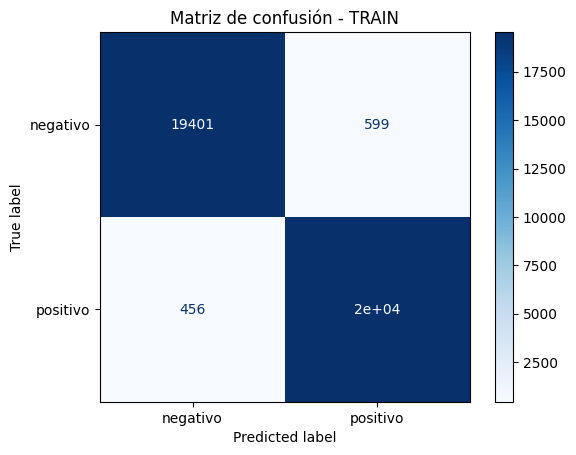

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

    #TRAIN
#DataLoader de entrenamiento
train_eval_df = pd.DataFrame({
    'review_es': X_train_text,
    'label': (y_train == 'positivo').astype(int)
})

train_eval_loader = data_loader(train_eval_df, tokenizer, MAX_LEN, BATCH_SIZE)

#Predicciones y métricas en entrenamiento
y_train_pred = predict_model(model, train_eval_loader)
y_train_true = train_eval_df['label'].values

print("\n Reporte de clasificación en train:")
print(classification_report(y_train_true, y_train_pred, labels=[0, 1], target_names=['negativo', 'positivo'], digits=4))
print("Distribución etiquetas reales:", np.bincount(y_train_true))
print("Distribución etiquetas predichas:", np.bincount(y_train_pred))

print("\n")

y_train_true_labels = np.where(y_train_true == 1, "positivo", "negativo")
y_train_pred_labels = np.where(y_train_pred == 1, "positivo", "negativo")
evaluar(y_train_true_labels, y_train_pred_labels, "Métricas de entrenamiento")

#Matriz de confusión
cm_train = confusion_matrix(y_train_true, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['negativo', 'positivo'])
disp_train.plot(cmap='Blues')
plt.title("Matriz de confusión - TRAIN")
plt.show()



 Reporte de clasificación en validación:
              precision    recall  f1-score   support

    negativo     0.9771    0.9720    0.9745      5000
    positivo     0.9721    0.9772    0.9747      5000

    accuracy                         0.9746     10000
   macro avg     0.9746    0.9746    0.9746     10000
weighted avg     0.9746    0.9746    0.9746     10000

Distribución etiquetas reales: [5000 5000]
Distribución etiquetas predichas: [4974 5026]


--- Métricas de validación ---
Accuracy : 0.9746
Precision: 0.9721
Recall   : 0.9772
F1 Score : 0.9747



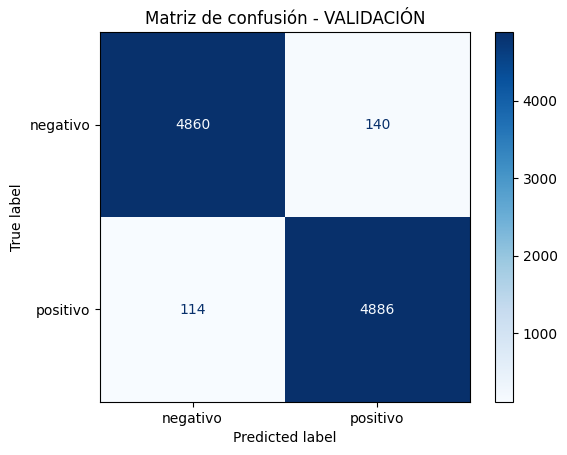

In [39]:
    #VALIDACIÓN
#DataLoader de validación
val_df = pd.DataFrame({
    'review_es': X_val_text,
    'label': (y_val == 'positivo').astype(int)
})
val_data_loader = data_loader(val_df, tokenizer, MAX_LEN, BATCH_SIZE)

#Predicciones y métricas en validación
y_val_pred = predict_model(model, val_data_loader)
y_val_true = val_df['label'].values

print("\n Reporte de clasificación en validación:")
print(classification_report(y_val_true, y_val_pred, labels=[0,1], target_names=['negativo', 'positivo'], digits=4))
print("Distribución etiquetas reales:", np.bincount(y_val_true))
print("Distribución etiquetas predichas:", np.bincount(y_val_pred))

print("\n")

y_val_true_labels = np.where(y_val_true == 1, "positivo", "negativo")
y_val_pred_labels = np.where(y_val_pred == 1, "positivo", "negativo")
evaluar(y_val_true_labels, y_val_pred_labels, "Métricas de validación")

#Matriz de confusión
cm_val = confusion_matrix(y_val_true, y_val_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['negativo', 'positivo'])
disp_val.plot(cmap='Blues')
plt.title("Matriz de confusión - VALIDACIÓN")
plt.show()


Predecimos sobre test y armamos la submission de Kaggle

In [40]:
    #SUBMISSION

#DataLoader de test
test_data_loader = get_test_loader(test_df, tokenizer, MAX_LEN, BATCH_SIZE)

#Predicciones en test
y_test_pred = predict_model(model, test_data_loader)

#Convertimos a etiquetas
y_test_pred_labels = np.where(y_test_pred == 1, "positivo", "negativo")

submission = pd.DataFrame({
    "ID": test_df["ID"],
    "sentimiento": y_test_pred_labels
})



In [41]:
#Guardar CSV
from google.colab import files
submission.to_csv("submission_rn.csv", index=False)
files.download("submission_rn.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>